<div style="background: linear-gradient(to bottom, #461EBE, #006EC7); padding: 24px 28px; border-radius: 12px; color: white;">

# Dataset Exploration  — `data/icons_filtered.jsonl`
Explores the 275,912 license-filtered icons: monochrome vs. multicolor split,
path count distribution, and SVG string length.

</div>

In [211]:
import json
import re
import sys
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, "..")
from brand import BRAND, blue, purple, orange, green, pink, teal, white, black, dark_bg

plt.style.use("dark_background")
mpl.rcParams.update({
    "figure.facecolor":  dark_bg,
    "axes.facecolor":    dark_bg,
    "axes.edgecolor":    blue,
    "axes.labelcolor":   white,
    "xtick.color":       white,
    "ytick.color":       white,
    "text.color":        white,
    "legend.framealpha": 1.0,
    "legend.edgecolor":  blue,
    "legend.facecolor":  dark_bg,
    "font.family":       "sans-serif",
})

In [212]:
DATA = Path("../data/icons_filtered.jsonl")

records = []
with open(DATA) as f:
    for line in f:
        if line.strip():
            records.append(json.loads(line))

print(f"Total icons loaded: {len(records):,}")

Total icons loaded: 275,912


In [213]:
_ATTR_COLOR = re.compile(
    r'(?:fill|stroke|stop-color|color)\s*=\s*["\']([^"\']+)["\']',
    re.IGNORECASE,
)
_STYLE_COLOR = re.compile(
    r'(?:fill|stroke|stop-color|color)\s*:\s*([^;"\'\s>]+)',
    re.IGNORECASE,
)
_SKIP_COLORS = frozenset({"currentcolor", "none", "inherit", "transparent", ""})

def _classify(svg: str) -> str:
    vals = _ATTR_COLOR.findall(svg) + _STYLE_COLOR.findall(svg)
    colors = {v.strip().lower() for v in vals if v.strip().lower() not in _SKIP_COLORS}
    if not colors:
        return "monochrome"
    return "single_color" if len(colors) == 1 else "multicolor"

for r in records:
    if "color_class" not in r:
        r["color_class"] = _classify(r["svg"])

## 1. Color Classification

In [214]:
mono   = [r for r in records if r["color_class"] == "monochrome"]
single = [r for r in records if r["color_class"] == "single_color"]
multi  = [r for r in records if r["color_class"] == "multicolor"]

total = len(records)
print(f"Monochrome (currentColor)      : {len(mono):>7,}  ({len(mono)/total*100:.1f}%)")
print(f"Single-color → currentColor    : {len(single):>7,}  ({len(single)/total*100:.1f}%)")
print(f"Multicolor (excluded)          : {len(multi):>7,}  ({len(multi)/total*100:.1f}%)")
print(f"Total                          : {total:>7,}")

Monochrome (currentColor)      : 226,487  (82.1%)
Single-color → currentColor    :   6,167  (2.2%)
Multicolor (excluded)          :  43,258  (15.7%)
Total                          : 275,912


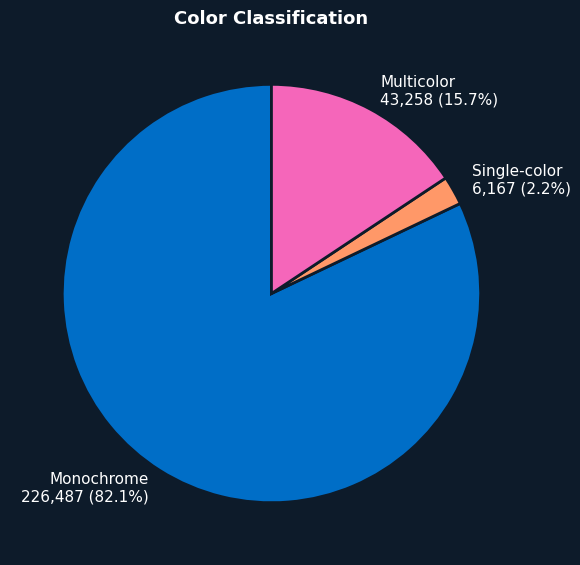

In [215]:
fig, ax = plt.subplots(figsize=(6, 6), facecolor=dark_bg)
ax.pie(
    [len(mono), len(single), len(multi)],
    labels=[
        f"Monochrome\n{len(mono):,} ({len(mono)/total*100:.1f}%)",
        f"Single-color\n{len(single):,} ({len(single)/total*100:.1f}%)",
        f"Multicolor\n{len(multi):,} ({len(multi)/total*100:.1f}%)",
    ],
    colors=[blue, orange, pink],
    startangle=90,
    wedgeprops=dict(linewidth=2, edgecolor=dark_bg),
    textprops=dict(color=white, fontsize=11),
)
ax.set_title("Color Classification", fontsize=13, color=white, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Average Path Count

In [216]:
mono_paths   = np.array([r["path_count"] for r in mono])
single_paths = np.array([r["path_count"] for r in single])
multi_paths  = np.array([r["path_count"] for r in multi])

print(f"{'':30s}  {'mean':>6}  {'median':>6}  {'max':>6}")
print("-" * 55)
print(f"{'Monochrome':30s}  {mono_paths.mean():6.1f}  {np.median(mono_paths):6.1f}  {mono_paths.max():6,}")
print(f"{'Single-color (→ currentColor)':30s}  {single_paths.mean():6.1f}  {np.median(single_paths):6.1f}  {single_paths.max():6,}")
print(f"{'Multicolor':30s}  {multi_paths.mean():6.1f}  {np.median(multi_paths):6.1f}  {multi_paths.max():6,}")

                                  mean  median     max
-------------------------------------------------------
Monochrome                         1.4     1.0      40
Single-color (→ currentColor)      1.9     1.0      25
Multicolor                        10.9     4.0     895


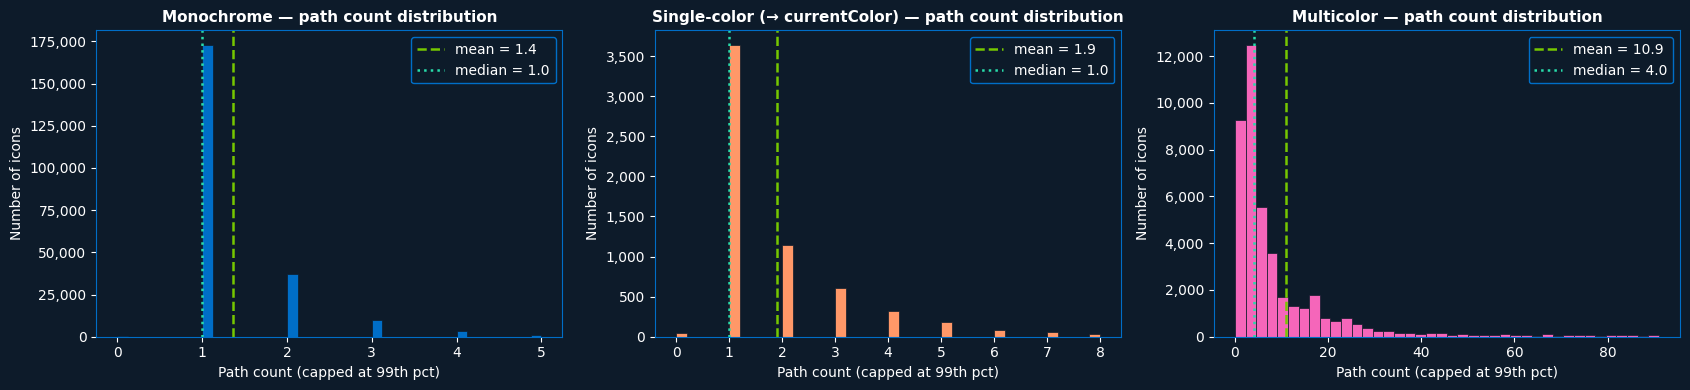

In [217]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4), facecolor=dark_bg)

for ax, paths, label, color in zip(
    axes,
    [mono_paths, single_paths, multi_paths],
    ["Monochrome", "Single-color (→ currentColor)", "Multicolor"],
    [blue, orange, pink],
):
    cap = int(np.percentile(paths, 99))
    ax.hist(paths[paths <= cap], bins=40, color=color, edgecolor=dark_bg, linewidth=0.5)
    ax.axvline(paths.mean(), color=green, linestyle="--", linewidth=1.8,
               label=f"mean = {paths.mean():.1f}")
    ax.axvline(np.median(paths), color=teal, linestyle=":", linewidth=1.8,
               label=f"median = {np.median(paths):.1f}")
    ax.set_title(f"{label} — path count distribution", fontsize=11, fontweight="bold")
    ax.set_xlabel("Path count (capped at 99th pct)")
    ax.set_ylabel("Number of icons")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for spine in ax.spines.values():
        spine.set_edgecolor(blue)
    ax.legend()

plt.tight_layout()
plt.show()

## 3. Average SVG String Length

In [218]:
mono_len   = np.array([len(r["svg"]) for r in mono])
single_len = np.array([len(r["svg"]) for r in single])
multi_len  = np.array([len(r["svg"]) for r in multi])

print(f"{'':30s}  {'mean':>8}  {'median':>8}  {'max':>8}  chars")
print("-" * 65)
print(f"{'Monochrome':30s}  {mono_len.mean():8.0f}  {np.median(mono_len):8.0f}  {mono_len.max():8,}")
print(f"{'Single-color (→ currentColor)':30s}  {single_len.mean():8.0f}  {np.median(single_len):8.0f}  {single_len.max():8,}")
print(f"{'Multicolor':30s}  {multi_len.mean():8.0f}  {np.median(multi_len):8.0f}  {multi_len.max():8,}")

                                    mean    median       max  chars
-----------------------------------------------------------------
Monochrome                           677       496   155,610
Single-color (→ currentColor)       1063       607   106,516
Multicolor                          4498      1446   869,523


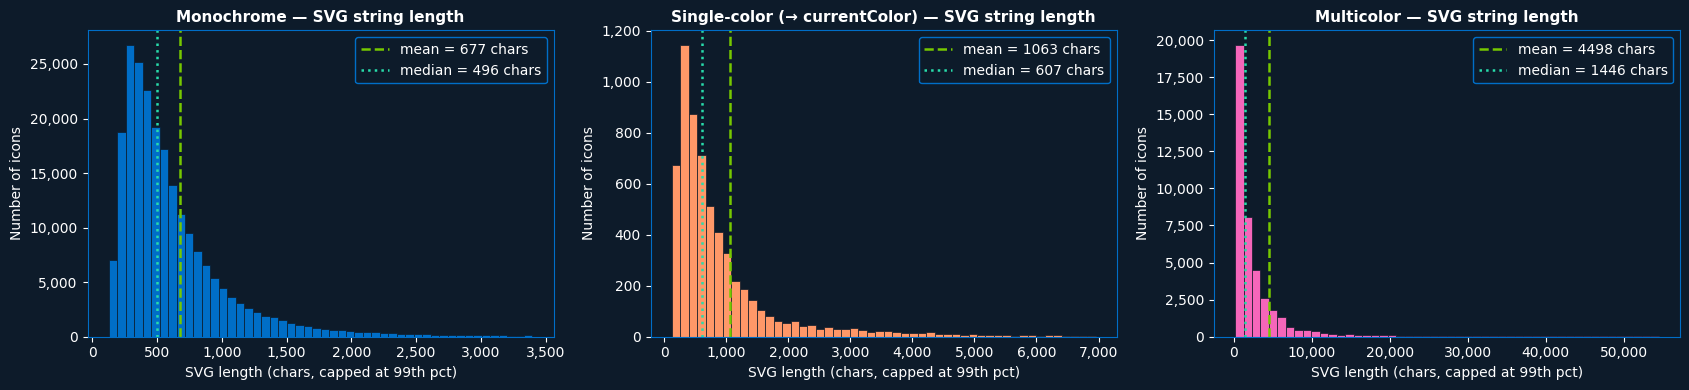

In [219]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4), facecolor=dark_bg)

for ax, lengths, label, color in zip(
    axes,
    [mono_len, single_len, multi_len],
    ["Monochrome", "Single-color (→ currentColor)", "Multicolor"],
    [blue, orange, pink],
):
    cap = int(np.percentile(lengths, 99))
    ax.hist(lengths[lengths <= cap], bins=50, color=color, edgecolor=dark_bg, linewidth=0.5)
    ax.axvline(lengths.mean(), color=green, linestyle="--", linewidth=1.8,
               label=f"mean = {lengths.mean():.0f} chars")
    ax.axvline(np.median(lengths), color=teal, linestyle=":", linewidth=1.8,
               label=f"median = {np.median(lengths):.0f} chars")
    ax.set_title(f"{label} — SVG string length", fontsize=11, fontweight="bold")
    ax.set_xlabel("SVG length (chars, capped at 99th pct)")
    ax.set_ylabel("Number of icons")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for spine in ax.spines.values():
        spine.set_edgecolor(blue)
    ax.legend()

plt.tight_layout()
plt.show()

## 4. Summary Table

In [220]:
import pandas as pd

summary = pd.DataFrame({
    "Category": ["Monochrome", "Single-color → currentColor", "Multicolor"],
    "Count": [len(mono), len(single), len(multi)],
    "Share (%)": [
        f"{len(mono)/total*100:.1f}",
        f"{len(single)/total*100:.1f}",
        f"{len(multi)/total*100:.1f}",
    ],
    "Avg paths": [
        f"{mono_paths.mean():.1f}",
        f"{single_paths.mean():.1f}",
        f"{multi_paths.mean():.1f}",
    ],
    "Median paths": [
        f"{np.median(mono_paths):.1f}",
        f"{np.median(single_paths):.1f}",
        f"{np.median(multi_paths):.1f}",
    ],
    "Min paths": [
        f"{mono_paths.min()}",
        f"{single_paths.min()}",
        f"{multi_paths.min()}",
    ],
    "Max paths": [
        f"{mono_paths.max()}",
        f"{single_paths.max()}",
        f"{multi_paths.max()}",
    ],
    "Avg SVG len (chars)": [
        f"{mono_len.mean():.0f}",
        f"{single_len.mean():.0f}",
        f"{multi_len.mean():.0f}",
    ],
    "Median SVG len": [
        f"{np.median(mono_len):.0f}",
        f"{np.median(single_len):.0f}",
        f"{np.median(multi_len):.0f}",
    ],
    "Min SVG len": [
        f"{mono_len.min():,}",
        f"{single_len.min():,}",
        f"{multi_len.min():,}",
    ],
    "Max SVG len": [
        f"{mono_len.max():,}",
        f"{single_len.max():,}",
        f"{multi_len.max():,}",
    ],
})

summary.set_index("Category", inplace=True)
summary

,Count,Share (%),Avg paths,Median paths,Min paths,Max paths,Avg SVG len (chars),Median SVG len,Min SVG len,Max SVG len
Category,,,,,,,,,,
Monochrome,226487,82.1,1.4,1.0,0,40,677,496,126,"155,610"
Single-color → currentColor,6167,2.2,1.9,1.0,0,25,1063,607,126,"106,516"
Multicolor,43258,15.7,10.9,4.0,0,895,4498,1446,167,"869,523"


## 5. Visual Inspection — Single-color Icons by Path Count

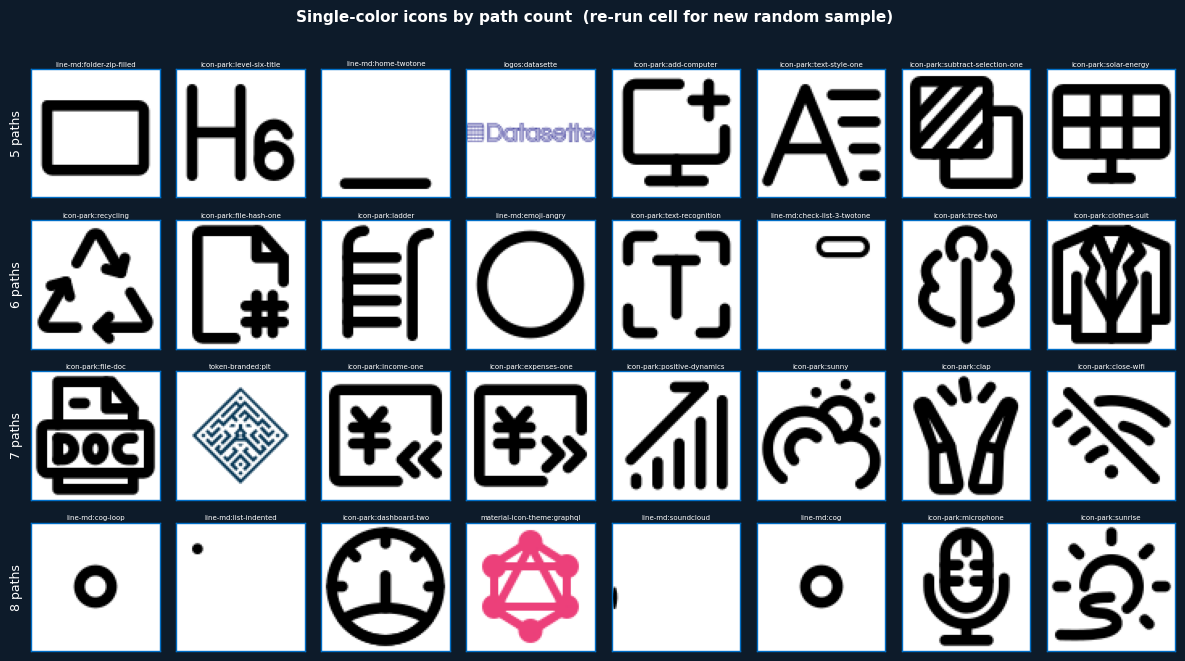

In [221]:
import io
import random
import cairosvg
from PIL import Image

def _svg_to_img(svg_str: str, size: int = 80) -> np.ndarray:
    png = cairosvg.svg2png(
        bytestring=svg_str.encode(),
        output_width=size,
        output_height=size,
        background_color="white",
    )
    return np.array(Image.open(io.BytesIO(png)).convert("RGB"))

rows_paths = [5, 6, 7, 8]
n_cols = 8

fig, axes = plt.subplots(
    len(rows_paths), n_cols,
    figsize=(n_cols * 1.5, len(rows_paths) * 1.5 + 0.5),
    facecolor=dark_bg,
)
fig.subplots_adjust(hspace=0.3, wspace=0.08)

for row_i, n_paths in enumerate(rows_paths):
    pool = [r for r in single if r["path_count"] == n_paths]
    sample = random.sample(pool, min(n_cols, len(pool))) if pool else []
    for col_i in range(n_cols):
        ax = axes[row_i, col_i]
        ax.set_facecolor("white")
        for spine in ax.spines.values():
            spine.set_edgecolor(blue)
            spine.set_linewidth(1.0)
        ax.set_xticks([])
        ax.set_yticks([])
        if col_i < len(sample):
            ax.imshow(_svg_to_img(sample[col_i]["svg"]))
            ax.set_title(sample[col_i]["icon_id"], fontsize=5, color=white, pad=2)
        if col_i == 0:
            ax.set_ylabel(f"{n_paths} paths", color=white, fontsize=9, labelpad=6)

fig.suptitle("Single-color icons by path count  (re-run cell for new random sample)",
             color=white, fontsize=11, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 6. Animated vs. Static

In [222]:
import pandas as pd

_ANIM_RE = re.compile(r'<animate|<set[\s>/]|@keyframes|animation\s*:', re.IGNORECASE)

for r in records:
    if "is_animated" not in r:
        r["is_animated"] = bool(_ANIM_RE.search(r["svg"]))

n_animated = sum(1 for r in records if r["is_animated"])
n_static   = total - n_animated

print(f"Static   : {n_static:>7,}  ({n_static/total*100:.1f}%)")
print(f"Animated : {n_animated:>7,}  ({n_animated/total*100:.1f}%)")
print()

cross_rows = []
for cls in ["monochrome", "single_color", "multicolor"]:
    subset = [r for r in records if r["color_class"] == cls]
    n_anim = sum(1 for r in subset if r["is_animated"])
    n_stat = len(subset) - n_anim
    cross_rows.append({
        "color_class": cls,
        "static": n_stat, "animated": n_anim,
        "total": len(subset),
        "anim_%": round(n_anim / len(subset) * 100, 2),
    })
    flag = "  ← contains animated!" if cls == "monochrome" and n_anim > 0 else ""
    print(f"  {cls:<15}  static={n_stat:>7,}  animated={n_anim:>6,}  ({n_anim/len(subset)*100:.2f}%){flag}")

cross = pd.DataFrame(cross_rows).set_index("color_class")
cross

Static   : 274,240  (99.4%)
Animated :   1,672  (0.6%)

  monochrome       static=226,442  animated=    45  (0.02%)  ← contains animated!
  single_color     static=  5,382  animated=   785  (12.73%)
  multicolor       static= 42,416  animated=   842  (1.95%)


,static,animated,total,anim_%
color_class,,,,
monochrome,226442,45,226487,0.02
single_color,5382,785,6167,12.73
multicolor,42416,842,43258,1.95


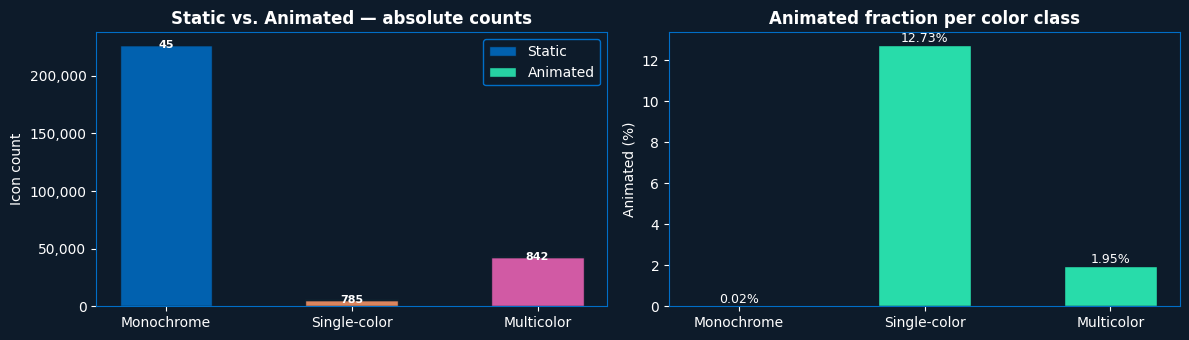

In [223]:
cats       = ["monochrome", "single_color", "multicolor"]
labels     = ["Monochrome", "Single-color", "Multicolor"]
cat_colors = [blue, orange, pink]

static_counts   = [cross.loc[c, "static"]   for c in cats]
animated_counts = [cross.loc[c, "animated"] for c in cats]
pcts            = [cross.loc[c, "anim_%"]   for c in cats]
x = np.arange(len(cats))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), facecolor=dark_bg)

# Left: stacked absolute counts
ax = axes[0]
ax.bar(x, static_counts, color=cat_colors, alpha=0.85, edgecolor=dark_bg, width=0.5, label="Static")
bars_a = ax.bar(x, animated_counts, color=teal, alpha=0.95, bottom=static_counts,
                edgecolor=dark_bg, width=0.5, label="Animated")
for bar, anim in zip(bars_a, animated_counts):
    if anim > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                f"{anim:,}", ha="center", va="center", color=white, fontsize=8, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Icon count")
ax.set_title("Static vs. Animated — absolute counts", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
for spine in ax.spines.values():
    spine.set_edgecolor(blue)
ax.legend()

# Right: animated % per color class
ax2 = axes[1]
bars = ax2.bar(x, pcts, color=teal, edgecolor=dark_bg, width=0.5)
for bar, pct in zip(bars, pcts):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"{pct:.2f}%", ha="center", va="bottom", color=white, fontsize=9)
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylabel("Animated (%)")
ax2.set_title("Animated fraction per color class", fontweight="bold")
for spine in ax2.spines.values():
    spine.set_edgecolor(blue)

plt.tight_layout()
plt.show()

## 7. Final Sample

In [224]:
def _to_monochrome(svg: str) -> str:
    svg = re.sub(
        r'((?:fill|stroke|stop-color|color)\s*=\s*["\'])([^"\']+)(["\'])',
        lambda m: m.group(1) + "currentColor" + m.group(3)
            if m.group(2).strip().lower() not in _SKIP_COLORS else m.group(0),
        svg, flags=re.IGNORECASE,
    )
    svg = re.sub(
        r'((?:fill|stroke|stop-color|color)\s*:\s*)([^;"\'\s>]+)',
        lambda m: m.group(1) + "currentColor"
            if m.group(2).strip().lower() not in _SKIP_COLORS else m.group(0),
        svg, flags=re.IGNORECASE,
    )
    return svg

def _ensure_currentcolor(svg: str) -> str:
    """Icons with no explicit fill rely on SVG default (black); make that explicit."""
    if re.search(r'currentColor', svg, re.IGNORECASE):
        return svg
    return re.sub(r'(<svg\b)', r'\1 fill="currentColor"', svg, count=1, flags=re.IGNORECASE)

_mono_cands   = [
    {**r, "svg": _ensure_currentcolor(r["svg"])}
    for r in mono if not r["is_animated"]
]
_single_cands = [
    {**r, "svg": _ensure_currentcolor(_to_monochrome(r["svg"])), "color_class": "monochrome"}
    for r in single if not r["is_animated"]
]
_candidates   = _mono_cands + _single_cands

cand_df     = pd.DataFrame(_candidates)
svg_lengths = cand_df["svg"].apply(len)

print(f"Monochrome non-animated              : {len(_mono_cands):,}")
print(f"Single-color non-animated (recolored): {len(_single_cands):,}")
print(f"Combined candidates                  : {len(_candidates):,}")
print()
print("SVG string length (chars):")
print(f"  mean={svg_lengths.mean():.0f}  median={svg_lengths.median():.0f}  "
      f"min={svg_lengths.min():,}  max={svg_lengths.max():,}")
for p in [90, 95, 98, 99, 99.5]:
    print(f"  {p}th pct: {svg_lengths.quantile(p/100):.0f}")
print()

dist = (
    cand_df["path_count"].value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)
dist["cumulative_%"] = (dist["count"].cumsum() / dist["count"].sum() * 100).round(2)
dist.index.name = "path_count"
dist.head(10)

Monochrome non-animated              : 226,442
Single-color non-animated (recolored): 5,382
Combined candidates                  : 231,824

SVG string length (chars):
  mean=687  median=497  min=127  max=155,630
  90th pct: 1218
  95th pct: 1669
  98th pct: 2609
  99th pct: 3533
  99.5th pct: 4593



,count,cumulative_%
path_count,,
0,502,0.22
1,176379,76.30
2,37934,92.66
3,10449,97.17
4,3548,98.70
5,1311,99.27
6,690,99.56
7,359,99.72
8,218,99.81


### Adding `currentColor` to icons without explicit fill/stroke

Some monochrome icons carry no explicit `fill` or `stroke` attributes — they rely on SVG's implicit default fill (black). `_ensure_currentcolor` injects `fill="currentColor"` on the `<svg>` root so they respond to color substitution at render time.

Monochrome icons with no explicit fill (default black): 307


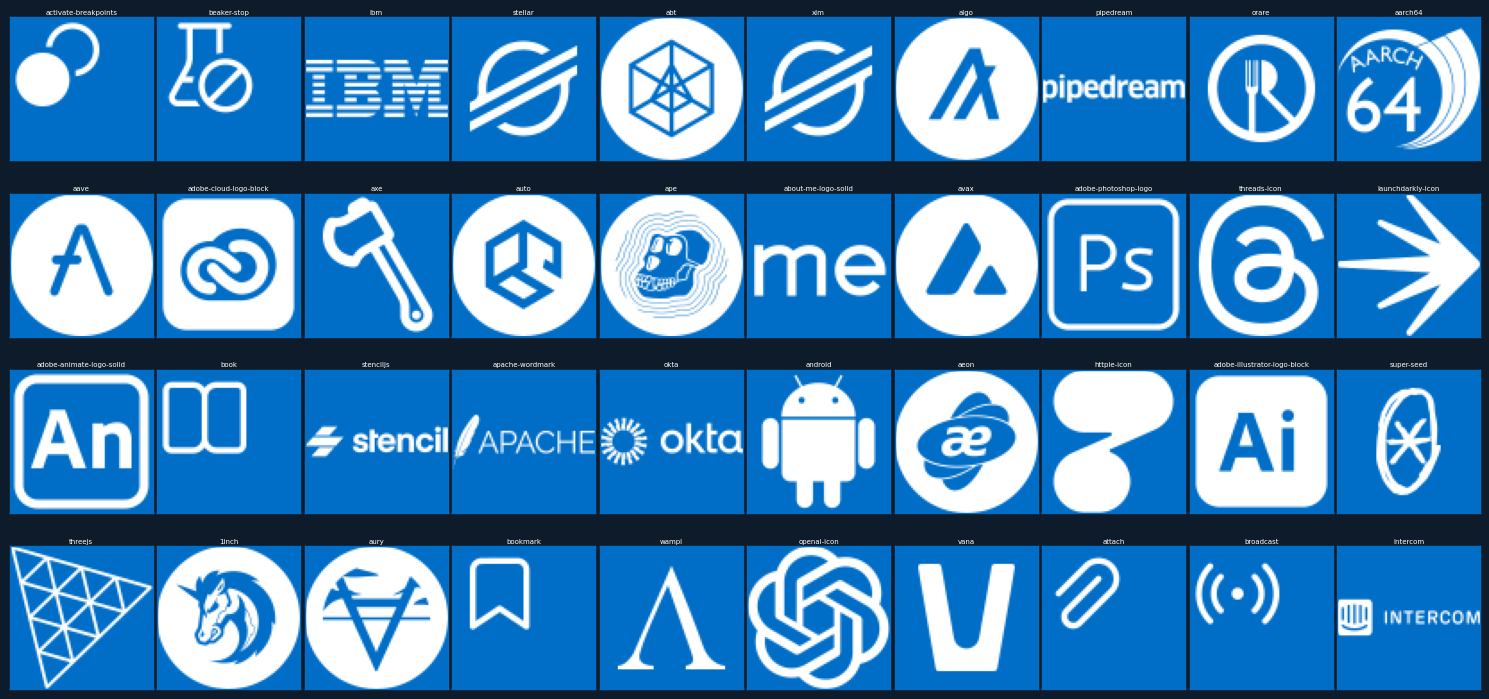

In [225]:
# Icons that had fill="currentColor" injected (no explicit fill/stroke in original)
_injected = [
    r for r, orig in zip(_mono_cands, mono)
    if not re.search(r'currentColor', orig["svg"], re.IGNORECASE)
    and not r["is_animated"]
]
print(f"Monochrome icons with no explicit fill (default black): {len(_injected):,}")

def _svg_to_img_white_on_blue(svg_str: str, size: int = 80) -> np.ndarray:
    colored = svg_str.replace("currentColor", white)
    png = cairosvg.svg2png(
        bytestring=colored.encode(),
        output_width=size, output_height=size,
        background_color=blue,
    )
    return np.array(Image.open(io.BytesIO(png)).convert("RGB"))

n_cols = 10
n_rows = 4
sample_inj = random.sample(_injected, min(n_cols * n_rows, len(_injected)))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.5, n_rows * 1.8), facecolor=dark_bg)
fig.subplots_adjust(hspace=0.55, wspace=0.08)

for i, ax in enumerate(axes.flat):
    ax.set_facecolor(blue)
    for spine in ax.spines.values():
        spine.set_edgecolor(blue)
        spine.set_linewidth(1.0)
    ax.set_xticks([])
    ax.set_yticks([])
    if i < len(sample_inj):
        ax.imshow(_svg_to_img_white_on_blue(sample_inj[i]["svg"]))
        name = sample_inj[i]["icon_id"].split(":", 1)[-1]
        ax.set_title(name, fontsize=5, color=white, pad=2)

plt.tight_layout()
plt.savefig("output/injected_currentcolor_samples.png", dpi=300, bbox_inches="tight")
plt.show()

### Logos and Brands

Logo/brand collections excluded (15):
  bxl                                    295
  cib                                    830
  cryptocurrency                         483
  emojione                               118
  fa-brands                              457
  fa6-brands                             495
  fa7-brands                             586
  fluent-emoji-flat                       93
  fxemoji                                151
  logos                                  709
  simple-icons                         3,423
  streamline-logos                     1,362
  token                                1,772
  token-branded                          901
  twemoji                                152

Total icons removed: 11,827
Final sample: 216,797 icons  (path count 1–5, SVG ≤ 3,533 chars [99th pct], logos excluded)


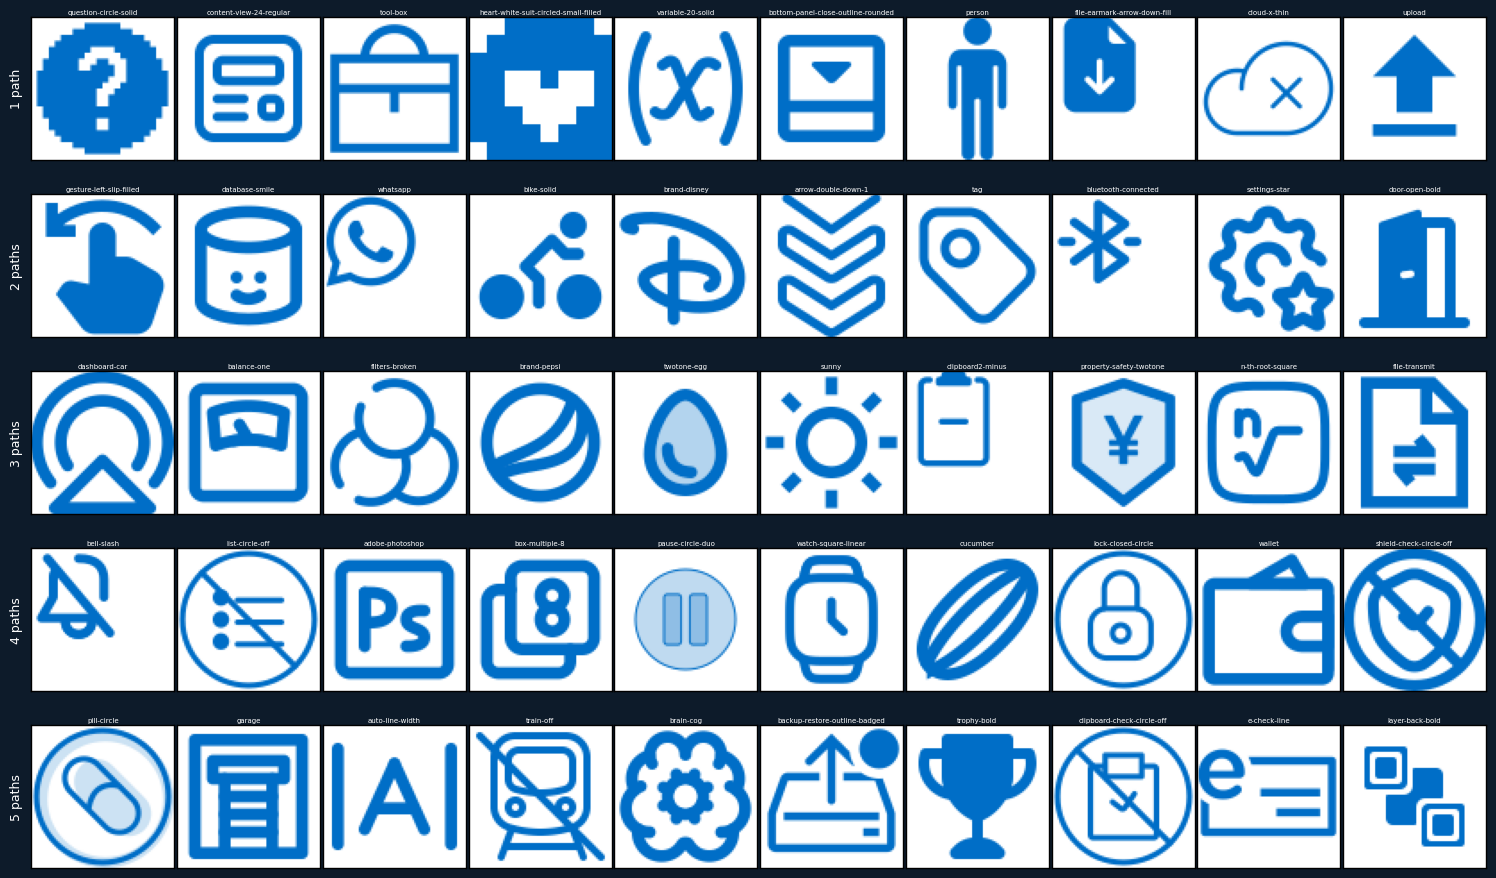

In [226]:
def _collection(r) -> str:
    return r["icon_id"].split(":", 1)[0]

# Identify logo/brand/flag/emoji collections by name pattern
_all_collections = sorted({_collection(r) for r in _candidates})
_LOGO_KEYWORDS   = ("logo", "brand", "flag", "emoji", "cryptocurrency", "token",
                     "simple-icons", "cib", "fa-brands", "bxl")
# Monochrome emoji sets are acceptable — keep them
_LOGO_KEEP = {"emojione-monotone", "fluent-emoji-high-contrast"}
_LOGO_COLLECTIONS = {
    c for c in _all_collections
    if any(kw in c.lower() for kw in _LOGO_KEYWORDS)
    and c not in _LOGO_KEEP
}

print(f"Logo/brand collections excluded ({len(_LOGO_COLLECTIONS)}):")
for c in sorted(_LOGO_COLLECTIONS):
    n = sum(1 for r in _candidates if _collection(r) == c)
    print(f"  {c:<35} {n:>6,}")

n_before = sum(1 for r in _candidates if _collection(r) in _LOGO_COLLECTIONS)
print(f"\nTotal icons removed: {n_before:,}")

_svg_len_cap = int(np.percentile([len(r["svg"]) for r in _candidates], 99))
final = [
    r for r in _candidates
    if r["path_count"] <= 5
    and len(r["svg"]) <= _svg_len_cap
    and _collection(r) not in _LOGO_COLLECTIONS
]
print(f"Final sample: {len(final):,} icons  "
      f"(path count 1–5, SVG ≤ {_svg_len_cap:,} chars [99th pct], logos excluded)")

def _svg_to_img_blue(svg_str: str, size: int = 80) -> np.ndarray:
    colored = svg_str.replace("currentColor", blue)
    png = cairosvg.svg2png(
        bytestring=colored.encode(),
        output_width=size,
        output_height=size,
        background_color="white",
    )
    return np.array(Image.open(io.BytesIO(png)).convert("RGB"))

n_rows, n_cols = 5, 10
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.5, n_rows * 1.8), facecolor=dark_bg)
fig.subplots_adjust(hspace=0.55, wspace=0.08)

for row_i in range(n_rows):
    n_paths = row_i + 1
    pool = [r for r in final if r["path_count"] == n_paths]
    sample = random.sample(pool, min(n_cols, len(pool))) if pool else []
    for col_i in range(n_cols):
        ax = axes[row_i, col_i]
        ax.set_facecolor("white")
        for spine in ax.spines.values():
            spine.set_edgecolor(black)
            spine.set_linewidth(1.0)
        ax.set_xticks([])
        ax.set_yticks([])
        if col_i < len(sample):
            ax.imshow(_svg_to_img_blue(sample[col_i]["svg"]))
            name = sample[col_i]["icon_id"].split(":", 1)[-1]
            ax.set_title(name, fontsize=5, color=white, pad=2)
        if col_i == 0:
            ax.set_ylabel(f"{n_paths} path{'s' if n_paths > 1 else ''}", color=white, fontsize=9, labelpad=6)

plt.tight_layout()
plt.savefig("output/final_sample.png", dpi=300, bbox_inches="tight")
plt.show()

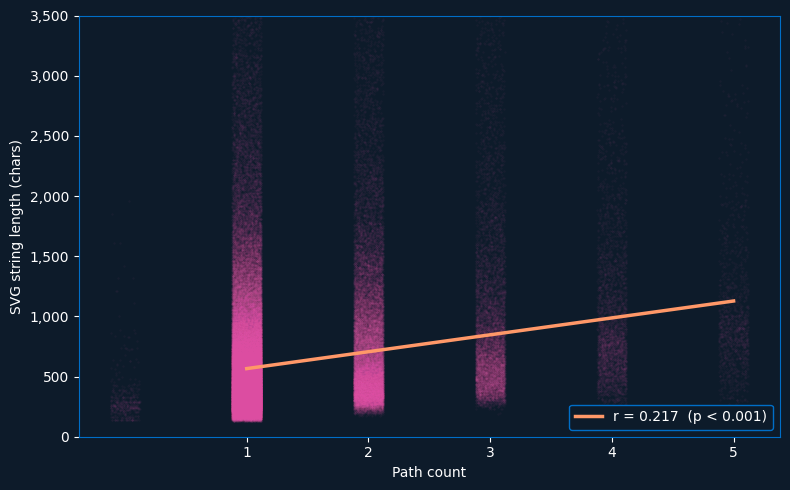

Pearson r = 0.2174  |  slope = 140.4 chars/path  |  p = 0.00e+00


In [227]:
from scipy import stats

final_paths = np.array([r["path_count"] for r in final])
final_lens  = np.array([len(r["svg"])   for r in final])

slope, intercept, r_value, p_value, _ = stats.linregress(final_paths, final_lens)
x_fit = np.linspace(1, 5, 100)
y_fit = slope * x_fit + intercept

fig, ax = plt.subplots(figsize=(8, 5), facecolor=dark_bg)
ax.scatter(
    final_paths + np.random.uniform(-0.12, 0.12, size=len(final_paths)),
    final_lens, color=pink, alpha=0.04, s=3, linewidths=0, rasterized=True,
)
ax.plot(x_fit, y_fit, color=orange, linewidth=2.5, label=f"r = {r_value:.3f}  (p < 0.001)")
ax.set_xlabel("Path count")
ax.set_ylabel("SVG string length (chars)")
#ax.set_title("Path count vs. SVG string length — final sample", fontweight="bold")
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_ylim(0, 3500)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for spine in ax.spines.values():
    spine.set_edgecolor(blue)
ax.legend()
plt.tight_layout()
plt.savefig("output/path_count_vs_svg_length.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Pearson r = {r_value:.4f}  |  slope = {slope:.1f} chars/path  |  p = {p_value:.2e}")

Unique tokens: 14,333   Total words: 561,653
Top 20:
  outline                22,996
  filled                 15,691
  rounded                11,435
  sharp                  10,301
  regular                 9,491
  fill                    8,452
  circle                  8,208
  arrow                   8,134
  solid                   7,735
  line                    6,779
  bold                    6,291
  20                      5,972
  off                     5,526
  24                      5,419
  16                      5,345
  duotone                 5,194
  right                   4,885
  square                  4,648
  left                    4,632
  up                      4,122


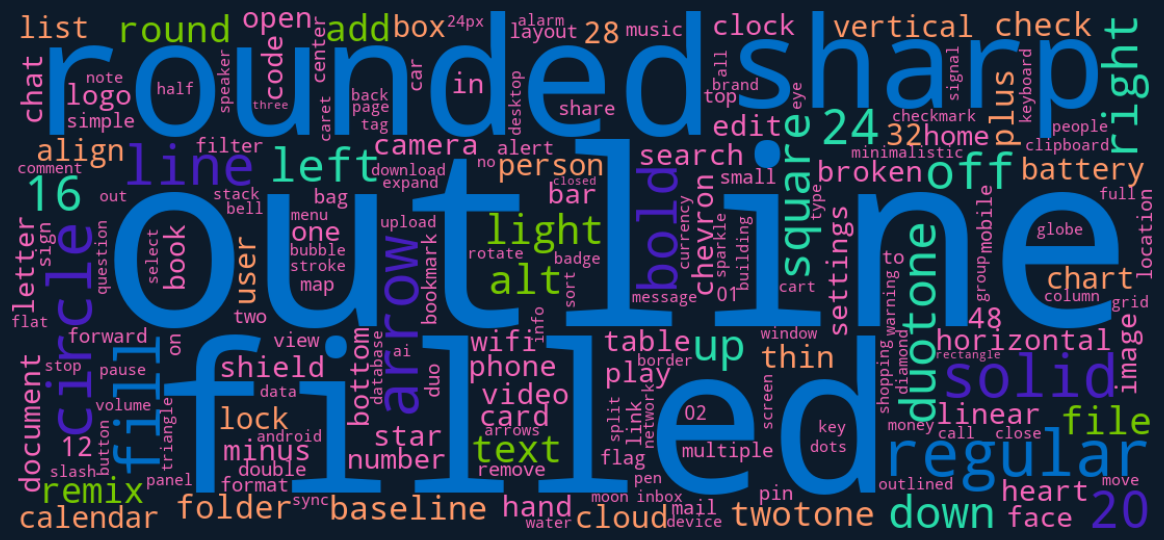

In [228]:
import subprocess, sys

from collections import Counter
from wordcloud import WordCloud

words = []
for r in final:
    name = r["icon_id"].split(":", 1)[-1]
    tokens = re.split(r"[-_\s]+", name.lower())
    words.extend(t for t in tokens if len(t) > 1)

freq = Counter(words)
print(f"Unique tokens: {len(freq):,}   Total words: {sum(freq.values()):,}")
print("Top 20:")
for w, c in freq.most_common(20):
    print(f"  {w:<22} {c:>6,}")

wc = WordCloud(
    width=1100, height=500,
    background_color="#0D1B2A",
    prefer_horizontal=0.80,
    max_words=200,
    min_font_size=8,
).generate_from_frequencies(freq)

# Recolor using the actual font sizes from this exact layout
_sizes = sorted(set(item[1] for item in wc.layout_), reverse=True)
_tier_colors = [blue, purple, teal, green, orange, pink]
_size_to_color = {
    s: _tier_colors[min(int(i / len(_sizes) * len(_tier_colors)), len(_tier_colors) - 1)]
    for i, s in enumerate(_sizes)
}

wc.recolor(color_func=lambda word, font_size, **kw: _size_to_color.get(font_size, pink))

fig, ax = plt.subplots(figsize=(13, 5.5), facecolor=dark_bg)
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
#ax.set_title("Most common words in icon names — final sample",color=white, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("output/wordcloud_final_sample.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. SVG Normalization

Four safe transforms applied before training — no visual information is lost for icons at the scale they are used:

| Step | What it removes | Rationale |
|------|----------------|-----------|
| Strip boilerplate | `<?xml?>`, `<!DOCTYPE>`, `<!-- comments -->` | Never part of icon semantics |
| Strip metadata | `<title>`, `<desc>`, `<metadata>` | Caption serves as the description |
| Reduce precision | floats with > 2 decimal places | 2 dp is visually indistinguishable for icon coordinates |
| Collapse whitespace | newlines, tabs, multi-spaces → single space | Reduces token count for the LM |

In [229]:
def _strip_boilerplate(svg: str) -> str:
    svg = re.sub(r'<\?xml[^?]*\?>', '', svg)
    svg = re.sub(r'<!DOCTYPE[^>]*>', '', svg)
    svg = re.sub(r'<!--.*?-->', '', svg, flags=re.DOTALL)
    return svg

def _strip_metadata(svg: str) -> str:
    for tag in ['title', 'desc', 'metadata']:
        svg = re.sub(fr'<{tag}[^>]*>.*?</{tag}>', '', svg, flags=re.DOTALL | re.IGNORECASE)
        svg = re.sub(fr'<{tag}\s*/>', '', svg, flags=re.IGNORECASE)
    return svg

def _reduce_precision(svg: str, dp: int = 2) -> str:
    return re.sub(r'-?\d+\.\d{3,}', lambda m: f"{float(m.group()):.{dp}f}", svg)

def _collapse_whitespace(svg: str) -> str:
    return re.sub(r'\s+', ' ', svg).strip()

def normalize_svg(svg: str) -> str:
    return _collapse_whitespace(_reduce_precision(_strip_metadata(_strip_boilerplate(svg))))

# Per-step stats on the full final sample
pipeline = [
    ("original",            lambda s: s),
    ("+ strip boilerplate", lambda s: _strip_boilerplate(s)),
    ("+ strip metadata",    lambda s: _strip_metadata(_strip_boilerplate(s))),
    ("+ reduce precision",  lambda s: _reduce_precision(_strip_metadata(_strip_boilerplate(s)))),
    ("+ collapse ws",       normalize_svg),
]

orig_svgs = [r["svg"] for r in final]
rows = []
for name, fn in pipeline:
    lens     = np.array([len(fn(s)) for s in orig_svgs])
    orig_len = np.array([len(s) for s in orig_svgs])
    affected = np.sum(lens != orig_len) if name != "original" else 0
    rows.append({
        "step":        name,
        "mean chars":  int(lens.mean()),
        "median":      int(np.median(lens)),
        "max":         int(lens.max()),
        "mean Δ%":     round((lens.mean() - orig_len.mean()) / orig_len.mean() * 100, 1),
        "affected %":  round(affected / len(orig_svgs) * 100, 1) if name != "original" else "-",
    })

stats_df = pd.DataFrame(rows).set_index("step")
print(f"Final sample: {len(final):,} icons\n")
stats_df

Final sample: 216,797 icons



,mean chars,median,max,mean Δ%,affected %
step,,,,,
original,611,484,3533,0.0,-
+ strip boilerplate,611,484,3533,0.0,0.0
+ strip metadata,611,484,3533,0.0,0.0
+ reduce precision,588,471,3520,-3.8,61.9
+ collapse ws,588,471,3520,-3.8,61.9


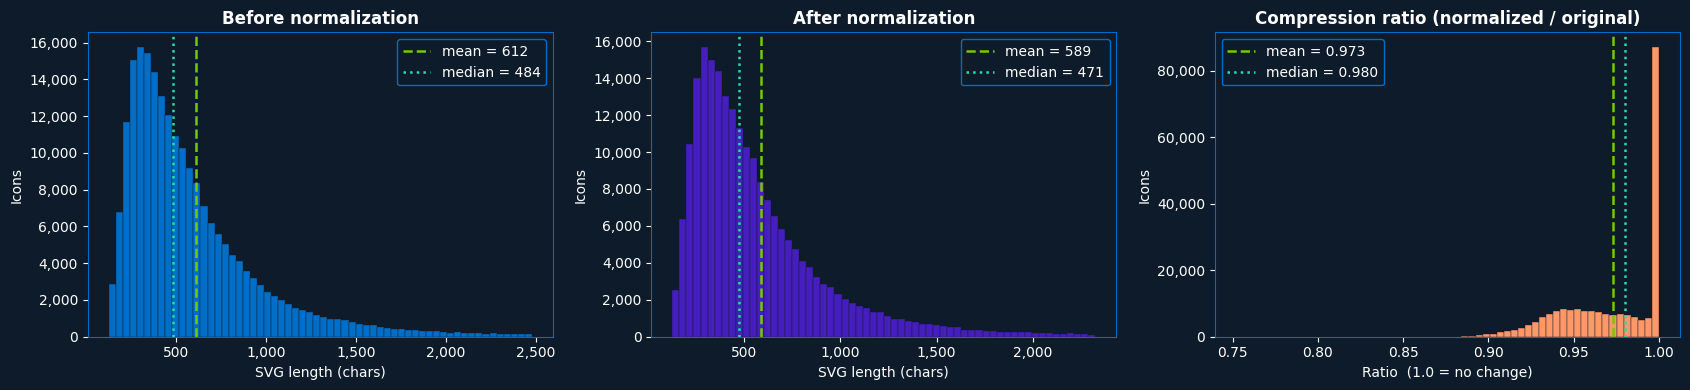

Example: fluent:box-search-16-regular  (640 → 609 chars, 95.2% of original)

── BEFORE ──
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 16 16" width="16" height="16"><path fill="currentColor" d="M10.077.379a3 3 0 0 0-2.154 0L2.962 2.287A1.5 1.5 0 0 0 2 3.687v2.57q.478-.17 1-.23V3.973L8.5 6.33v7.049l.442.442a3 3 0 0 0 1.135-.2l4.962-1.908a1.5 1.5 0 0 0 .961-1.4V3.687a1.5 1.5 0 0 0-.961-1.4zm-1.795.933a2 2 0 0 1 1.436 0l4.718 1.815l-1.947.834l-5.591-2.116zM9.5 6.33L15 3.973v6.34a.

── AFTER ──
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 16 16" width="16" height="16"><path fill="currentColor" d="M10.08.379a3 3 0 0 0-2.15 0L2.96 2.29A1.5 1.5 0 0 0 2 3.69v2.57q.478-.17 1-.23V3.97L8.5 6.33v7.05l.442.44a3 3 0 0 0 1.14-.2l4.96-1.91a1.5 1.5 0 0 0 .961-1.4V3.69a1.5 1.5 0 0 0-.961-1.4zm-1.79.933a2 2 0 0 1 1.44 0l4.72 1.81l-1.95.834l-5.59-2.12zM9.5 6.33L15 3.97v6.34a.5.5 0 0 1-.32.47l-4.


In [230]:
orig_lens = np.array([len(s)               for s in orig_svgs])
norm_lens = np.array([len(normalize_svg(s)) for s in orig_svgs])
ratios    = norm_lens / orig_lens

fig, axes = plt.subplots(1, 3, figsize=(17, 4), facecolor=dark_bg)

for ax, lens, label, color in zip(
    axes[:2],
    [orig_lens, norm_lens],
    ["Before normalization", "After normalization"],
    [blue, purple],
):
    cap = int(np.percentile(lens, 99))
    ax.hist(lens[lens <= cap], bins=60, color=color, edgecolor=dark_bg, linewidth=0.3)
    ax.axvline(lens.mean(),    color=green, linestyle="--", linewidth=1.8, label=f"mean = {lens.mean():.0f}")
    ax.axvline(np.median(lens), color=teal, linestyle=":",  linewidth=1.8, label=f"median = {np.median(lens):.0f}")
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("SVG length (chars)")
    ax.set_ylabel("Icons")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for spine in ax.spines.values():
        spine.set_edgecolor(blue)
    ax.legend()

ax = axes[2]
ax.hist(ratios, bins=60, color=orange, edgecolor=dark_bg, linewidth=0.3)
ax.axvline(ratios.mean(),    color=green, linestyle="--", linewidth=1.8, label=f"mean = {ratios.mean():.3f}")
ax.axvline(np.median(ratios), color=teal, linestyle=":",  linewidth=1.8, label=f"median = {np.median(ratios):.3f}")
ax.set_title("Compression ratio (normalized / original)", fontweight="bold")
ax.set_xlabel("Ratio  (1.0 = no change)")
ax.set_ylabel("Icons")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for spine in ax.spines.values():
    spine.set_edgecolor(blue)
ax.legend()

plt.tight_layout()
plt.show()

# Before / after example
ex = random.choice([r for r in final if len(r["svg"]) > 500])
norm_ex = normalize_svg(ex["svg"])
print(f"Example: {ex['icon_id']}  ({len(ex['svg'])} → {len(norm_ex)} chars, "
      f"{len(norm_ex)/len(ex['svg']):.1%} of original)\n")
print("── BEFORE ──")
print(ex["svg"][:400])
print("\n── AFTER ──")
print(norm_ex[:400])

### ViewBox Normalization

60% of the final sample is already 24×24; normalising the rest to the same space means the model always generates coordinates in [0, 24]. For icons not at 24×24 the coordinates are scaled by wrapping inner content in `<g transform="scale(sx sy)">` — this is visually lossless and correct, though a full coordinate rewrite (replacing numbers in path `d` attributes) would be cleaner for training. The transform approach is sufficient for exploration here.

Icons in final sample : 216,797
With viewBox          : 216,797  (100.0%)
Already 24×24         : 129,132  (59.6%)
Square viewBox        : 210,666  (97.2%)

viewBox size  count     %
       24×24 129132 59.56
     512×512  10514  4.85
       32×32   9273  4.28
     256×256   9227  4.26
       20×20   8654  3.99
       48×48   8595  3.96
       14×14   4956  2.29
       16×16   4265  1.97
       80×80   3324  1.53
     640×640   2271  1.05
       15×15   2227  1.03
   1024×1024   1987  0.92
       28×28   1818  0.84
   2048×2048   1805  0.83
       12×12   1792  0.83


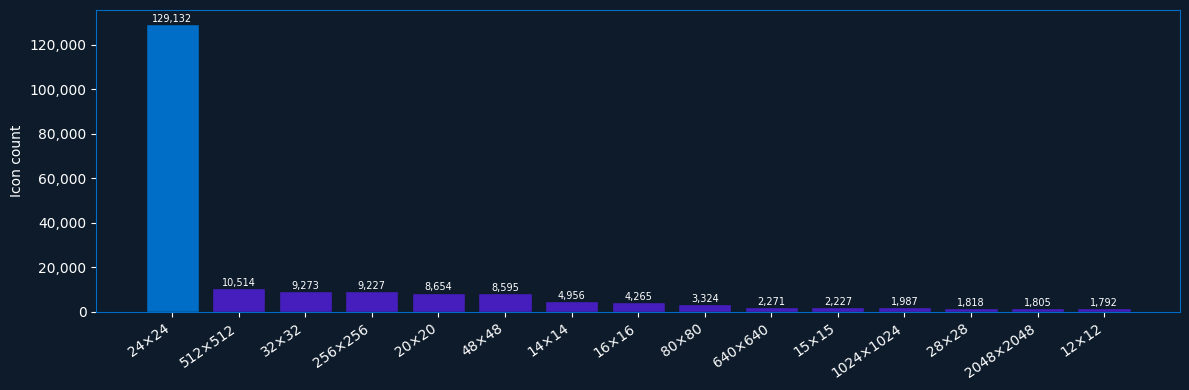

In [231]:
_VB_RE = re.compile(r'viewBox=["\']([^"\']+)["\']', re.IGNORECASE)

def _get_viewbox(svg: str):
    m = _VB_RE.search(svg)
    if not m:
        return None
    parts = m.group(1).strip().split()
    return tuple(float(p) for p in parts) if len(parts) == 4 else None

# ViewBox distribution across the final sample
from collections import Counter

vb_all   = [_get_viewbox(r["svg"]) for r in final]
vb_valid = [vb for vb in vb_all if vb is not None]
vb_sizes = Counter((int(vb[2]), int(vb[3])) for vb in vb_valid)

print(f"Icons in final sample : {len(final):,}")
print(f"With viewBox          : {len(vb_valid):,}  ({len(vb_valid)/len(final)*100:.1f}%)")
print(f"Already 24×24         : {vb_sizes[(24,24)]:,}  ({vb_sizes[(24,24)]/len(vb_valid)*100:.1f}%)")
print(f"Square viewBox        : {sum(c for (w,h),c in vb_sizes.items() if w==h):,}  "
      f"({sum(c for (w,h),c in vb_sizes.items() if w==h)/len(vb_valid)*100:.1f}%)")
print()

top = vb_sizes.most_common(15)
top_df = pd.DataFrame(
    [(f"{w}×{h}", c, round(c/len(vb_valid)*100, 2)) for (w,h),c in top],
    columns=["viewBox size", "count", "%"],
)
print(top_df.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(12, 4), facecolor=dark_bg)
labels_vb = [f"{w}×{h}" for (w, h), _ in top]
counts_vb = [c for _, c in top]
colors_vb = [blue if (w, h) == (24, 24) else purple for (w, h), _ in top]
bars = ax.bar(range(len(top)), counts_vb, color=colors_vb, edgecolor=dark_bg)
for bar, c in zip(bars, counts_vb):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{c:,}", ha="center", va="bottom", color=white, fontsize=7)
ax.set_xticks(range(len(top)))
ax.set_xticklabels(labels_vb, rotation=35, ha="right")
ax.set_ylabel("Icon count")
#ax.set_title("ViewBox size distribution — final sample  (blue = target 24×24)", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for spine in ax.spines.values():
    spine.set_edgecolor(blue)
plt.tight_layout()
plt.savefig("output/viewbox_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Already 24×24    : 129,132  (59.6%)
Need rescaling   : 87,665  (40.4%)
  of which non-square viewBox: 6,131
Chars added by <g transform>:  mean +47  median +47  max +69


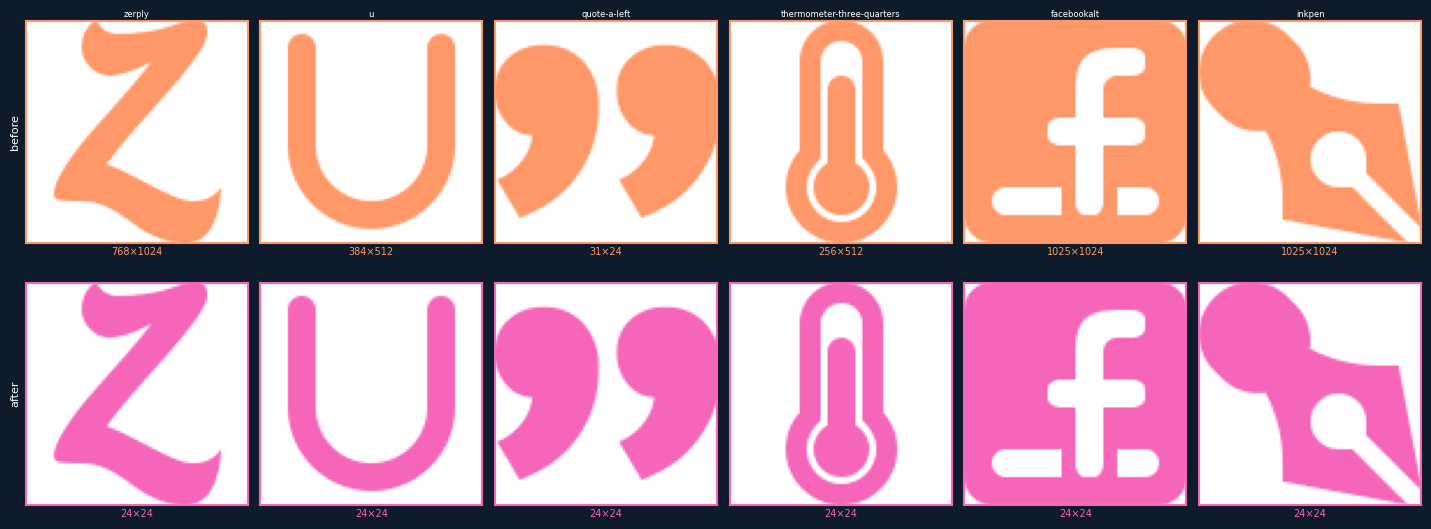

In [232]:
TARGET_VB = 24

def normalize_viewbox(svg: str, target: int = TARGET_VB) -> str:
    vb = _get_viewbox(svg)
    if vb is None:
        return svg
    vx, vy, vw, vh = vb
    if vw == target and vh == target and vx == 0 and vy == 0:
        return svg
    s  = target / max(vw, vh)
    ox = (target - vw * s) / 2 - vx * s
    oy = (target - vh * s) / 2 - vy * s
    transform = f"matrix({s:.6g} 0 0 {s:.6g} {ox:.4g} {oy:.4g})"
    svg = re.sub(r'viewBox=["\'][^"\']*["\']',
                 f'viewBox="0 0 {target} {target}"', svg, flags=re.IGNORECASE)
    m = re.search(r'(<svg[^>]*>)(.*)(</svg>)', svg, re.DOTALL | re.IGNORECASE)
    if m:
        svg = m.group(1) + f'<g transform="{transform}">' + m.group(2) + '</g>' + m.group(3)
    return svg

def _svg_to_img_color(svg_str: str, color: str, size: int = 96) -> np.ndarray:
    colored = svg_str.replace("currentColor", color)
    png = cairosvg.svg2png(bytestring=colored.encode(),
                           output_width=size, output_height=size, background_color="white")
    return np.array(Image.open(io.BytesIO(png)).convert("RGB"))

# Stats
needs_scale  = [r for r in final if _get_viewbox(r["svg"]) != (0.0, 0.0, float(TARGET_VB), float(TARGET_VB))]
already_norm = len(final) - len(needs_scale)
non_square   = [r for r in needs_scale
                if (lambda vb: vb is not None and vb[2] != vb[3])(_get_viewbox(r["svg"]))]
print(f"Already 24×24    : {already_norm:,}  ({already_norm/len(final)*100:.1f}%)")
print(f"Need rescaling   : {len(needs_scale):,}  ({len(needs_scale)/len(final)*100:.1f}%)")
print(f"  of which non-square viewBox: {len(non_square):,}")
lens_before = np.array([len(r["svg"]) for r in needs_scale])
lens_after  = np.array([len(normalize_viewbox(r["svg"])) for r in needs_scale])
delta = lens_after - lens_before
print(f"Chars added by <g transform>:  mean +{delta.mean():.0f}  "
      f"median +{np.median(delta):.0f}  max +{delta.max():.0f}")

# Visual check: only non-square → 24×24 (orange = before, blue = after)
sample_nonstd = random.sample(non_square, min(6, len(non_square)))
fig, axes = plt.subplots(2, len(sample_nonstd), figsize=(len(sample_nonstd) * 2.4, 5.5), facecolor=dark_bg)
fig.subplots_adjust(hspace=0.5, wspace=0.1)

for col, r in enumerate(sample_nonstd):
    vb        = _get_viewbox(r["svg"])
    vb_str    = f"{int(vb[2])}×{int(vb[3])}" if vb else "?"
    icon_name = r["icon_id"].split(":", 1)[-1]
    norm_svg  = normalize_viewbox(r["svg"])

    for row, (svg_str, border_color, icon_color) in enumerate([
        (r["svg"],  orange, orange),
        (norm_svg,  pink,   pink),
    ]):
        ax = axes[row, col]
        ax.set_facecolor("white")
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(1.5)
        ax.set_xticks([])
        ax.set_yticks([])
        try:
            ax.imshow(_svg_to_img_color(svg_str, icon_color, size=96))
        except Exception:
            ax.text(0.5, 0.5, "err", ha="center", va="center",
                    color="red", transform=ax.transAxes)
        if row == 0:
            ax.set_title(icon_name, fontsize=6, color=white, pad=3)
            ax.set_xlabel(vb_str, fontsize=7, color=orange, labelpad=3)
        else:
            ax.set_xlabel("24×24", fontsize=7, color=pink, labelpad=3)
        if col == 0:
            label = "before" if row == 0 else "after"
            ax.set_ylabel(label, color=white, fontsize=8)

#fig.suptitle("Non-square → 24×24 normalization  (orange = before, pink = after)",
#             color=white, fontsize=11, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("output/viewbox_normalization.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Summary Statistics

In [233]:
import textwrap
from matplotlib.patches import FancyBboxPatch

# ── TABLE 1: Data filtering pipeline ─────────────────────────────────────────

n_total = len(records)

def _pipeline_table():
    pool = list(records)
    rows = []

    def _row(step, prev_n, curr_n, note=""):
        removed = prev_n - curr_n
        return {
            "Step": step,
            "Icons remaining": curr_n,
            "Removed": removed if removed else 0,
            "% of corpus": round(curr_n / n_total * 100, 1),
            "Note": note,
        }

    rows.append({
        "Step": "Full Iconify corpus",
        "Icons remaining": n_total, "Removed": 0,
        "% of corpus": 100.0, "Note": "license-filtered JSONL",
    })

    prev = len(pool)
    pool = [r for r in pool if r["color_class"] != "multicolor"]
    rows.append(_row("Exclude multicolor icons", prev, len(pool),
                     f"keep monochrome ({len(mono):,}) + single-color ({len(single):,})"))

    prev = len(pool)
    pool = [r for r in pool if not r["is_animated"]]
    rows.append(_row("Exclude animated icons", prev, len(pool),
                     "<animate>, <set>, @keyframes, animation:"))

    rows.append({
        "Step": "  Convert single-color fill → currentColor",
        "Icons remaining": len(pool), "Removed": 0,
        "% of corpus": round(len(pool) / n_total * 100, 1),
        "Note": f"regex replacement on {len(single):,} single-color icons",
    })
    rows.append({
        "Step": "  Inject fill=\"currentColor\" on SVG root (default-fill icons)",
        "Icons remaining": len(pool), "Removed": 0,
        "% of corpus": round(len(pool) / n_total * 100, 1),
        "Note": "icons with no explicit fill/stroke attribute",
    })

    prev = len(pool)
    pool = [r for r in pool if r["icon_id"].split(":", 1)[0] not in _LOGO_COLLECTIONS]
    rows.append(_row("Exclude logo/brand/flag/emoji collections", prev, len(pool),
                     f"{len(_LOGO_COLLECTIONS)} collections removed"))

    prev = len(pool)
    pool = [r for r in pool if r["path_count"] <= 5]
    rows.append(_row("Exclude icons with > 5 paths", prev, len(pool),
                     "training focus: simple, generalisable icons"))

    prev = len(pool)
    pool = [r for r in pool if len(r["svg"]) <= _svg_len_cap]
    rows.append(_row(f"Exclude SVG > {_svg_len_cap:,} chars (99th pct)", prev, len(pool),
                     "remove outlier-length strings"))

    return pd.DataFrame(rows).set_index("Step")

pipe_df = _pipeline_table()
pipe_df["Icons remaining"] = pipe_df["Icons remaining"].map(lambda x: f"{x:,}")
pipe_df["Removed"]         = pipe_df["Removed"].map(lambda x: f"−{x:,}" if x else "—")
pipe_df["% of corpus"]     = pipe_df["% of corpus"].map(lambda x: f"{x:.1f}%")
print("Table 1 — Dataset filtering pipeline\n")
pipe_df

Table 1 — Dataset filtering pipeline



,Icons remaining,Removed,% of corpus,Note
Step,,,,
Full Iconify corpus,"275,912",—,100.0%,license-filtered JSONL
Exclude multicolor icons,"232,654","−43,258",84.3%,"keep monochrome (226,487) + single-color (6,167)"
Exclude animated icons,"231,824",−830,84.0%,"<animate>, <set>, @keyframes, animation:"
Convert single-color fill → currentColor,"231,824",—,84.0%,"regex replacement on 6,167 single-color icons"
"Inject fill=""currentColor"" on SVG root (default-fill icons)","231,824",—,84.0%,icons with no explicit fill/stroke attribute
Exclude logo/brand/flag/emoji collections,"219,997","−11,827",79.7%,15 collections removed
Exclude icons with > 5 paths,"218,392","−1,605",79.2%,"training focus: simple, generalisable icons"
"Exclude SVG > 3,533 chars (99th pct)","216,797","−1,595",78.6%,remove outlier-length strings


In [234]:
# ── TABLE 2: Final sample by path count ──────────────────────────────────────

path_rows = []
for n in range(1, 6):
    subset = [r for r in final if r["path_count"] == n]
    svgl   = [len(r["svg"]) for r in subset]
    path_rows.append({
        "Paths": n,
        "Icons": f"{len(subset):,}",
        "% of final": f"{len(subset)/len(final)*100:.1f}%",
        "SVG mean (chars)": f"{np.mean(svgl):.0f}",
        "SVG median": f"{np.median(svgl):.0f}",
        "SVG min": f"{min(svgl):,}",
        "SVG max": f"{max(svgl):,}",
    })

all_svgl = [len(r["svg"]) for r in final]
path_rows.append({
    "Paths": "Total",
    "Icons": f"{len(final):,}",
    "% of final": "100%",
    "SVG mean (chars)": f"{np.mean(all_svgl):.0f}",
    "SVG median": f"{np.median(all_svgl):.0f}",
    "SVG min": f"{min(all_svgl):,}",
    "SVG max": f"{max(all_svgl):,}",
})

final_breakdown = pd.DataFrame(path_rows).set_index("Paths")
print(f"Table 2 — Final sample ({len(final):,} icons) by path count\n")
final_breakdown

Table 2 — Final sample (216,797 icons) by path count



,Icons,% of final,SVG mean (chars),SVG median,SVG min,SVG max
Paths,,,,,,
1,"165,241",76.2%,566,453,127,"3,533"
2,"36,767",17.0%,706,542,170,"3,531"
3,"9,819",4.5%,840,644,191,"3,533"
4,"3,294",1.5%,1025,826,257,"3,527"
5,"1,198",0.6%,1068,912,273,"3,533"
Total,"216,797",100%,612,484,127,"3,533"


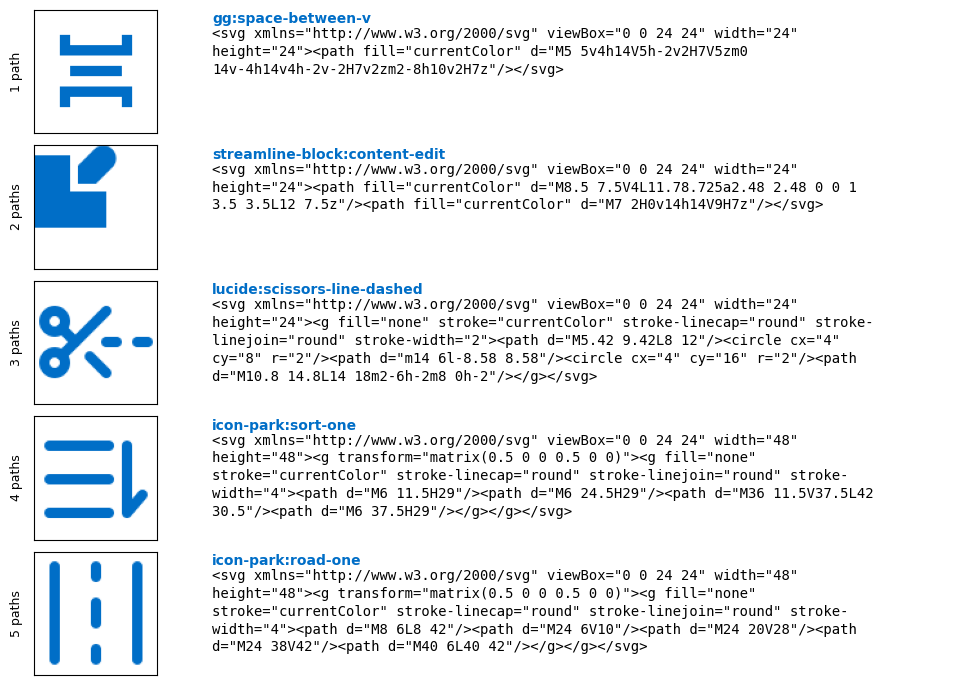

In [237]:
# ── FIGURE: Sample icons by path count + SVG code ────────────────────────────

def _render(svg_str: str, size: int = 100) -> np.ndarray:
    colored = re.sub(r'currentColor', blue, svg_str, flags=re.IGNORECASE)
    png = cairosvg.svg2png(
        bytestring=colored.encode(),
        output_width=size, output_height=size,
        background_color="white",
    )
    return np.array(Image.open(io.BytesIO(png)).convert("RGB"))

def _normalize_full(svg: str) -> str:
    return normalize_viewbox(normalize_svg(svg))

n_paths_rows = [1, 2, 3, 4, 5]

fig, axes = plt.subplots(
    len(n_paths_rows), 2,
    figsize=(10, 7),
    facecolor="white",
    gridspec_kw={"width_ratios": [1, 4.5]},
)
fig.subplots_adjust(left=0.06, right=0.99, top=0.97, bottom=0.02, hspace=0.1, wspace=0.06)

for row_i, n_paths in enumerate(n_paths_rows):
    pool = [
        r for r in final
        if r["path_count"] == n_paths
        and len(_normalize_full(r["svg"])) < 400
    ]

    # ── icon column ──
    ax_img = axes[row_i, 0]
    ax_img.set_facecolor("white")
    ax_img.set_xticks([])
    ax_img.set_yticks([])
    ax_img.set_aspect("equal", anchor="N")
    for sp in ax_img.spines.values():
        sp.set_edgecolor("black")
        sp.set_linewidth(0.8)
    ax_img.set_ylabel(
        f"{n_paths} path{'s' if n_paths > 1 else ''}",
        color="black", fontsize=9, labelpad=8,
    )

    # ── SVG code column ──
    ax_txt = axes[row_i, 1]
    ax_txt.set_facecolor("white")
    ax_txt.set_xlim(0, 1)
    ax_txt.set_ylim(0, 1)
    ax_txt.set_xticks([])
    ax_txt.set_yticks([])
    for sp in ax_txt.spines.values():
        sp.set_visible(False)

    if not pool:
        ax_img.text(0.5, 0.5, "no icons", ha="center", va="center",
                    color=blue, fontsize=8, transform=ax_img.transAxes)
        continue

    r = random.choice(pool)
    svg_full = _normalize_full(r["svg"])
    ax_img.imshow(_render(svg_full, size=96))

    svg_text = "\n".join(textwrap.wrap(svg_full, width=80))

    ax_txt.text(0.01, 0.98, r["icon_id"],
                ha="left", va="top", color=blue,
                fontsize=10, fontweight="bold",
                transform=ax_txt.transAxes)
    ax_txt.text(0.01, 0.86, svg_text,
                ha="left", va="top", color="black",
                fontsize=10, family="monospace", linespacing=1.35,
                transform=ax_txt.transAxes, clip_on=True)

plt.savefig("output/final_sample_svg_inspection.png", dpi=300, bbox_inches="tight")
plt.show()